# Multiple Linear Regression



## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [116]:
dataset = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')



X = dataset.drop(['name', 'selling_price'], axis=1)
y = dataset['selling_price']
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']

## EDA Steps

In [92]:
dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [93]:
dataset.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [94]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [95]:
dataset.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


## Preprocessing Steps

### 1. Preparing Data as input and output

In [96]:
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [97]:
print(X)

[['Maruti 800 AC' 2007 60000 ... 'Petrol' 'Individual' 'Manual']
 ['Maruti Wagon R LXI Minor' 2007 135000 ... 'Petrol' 'Individual'
  'Manual']
 ['Hyundai Verna 1.6 SX' 2012 600000 ... 'Diesel' 'Individual' 'Manual']
 ...
 ['Maruti 800 AC BSIII' 2009 110000 ... 'Petrol' 'Individual' 'Manual']
 ['Hyundai Creta 1.6 CRDi SX Option' 2016 865000 ... 'Diesel'
  'Individual' 'Manual']
 ['Renault KWID RXT' 2016 225000 ... 'Petrol' 'Individual' 'Manual']]


### 2. Encoding categorical data

In [98]:
dataset['name'].value_counts()

,count
name,
Maruti Swift Dzire VDI,69
Maruti Alto 800 LXI,59
Maruti Alto LXi,47
Hyundai EON Era Plus,35
Maruti Alto LX,35
...,...
Honda Brio 1.2 S Option MT,1
Mahindra Bolero Power Plus Plus Non AC BSIV PS,1
Tata Indigo LS BSII,1


In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[
    ('name_encoder', OneHotEncoder(handle_unknown='ignore'), [0]), # Handle unknown values during prediction
    ('fuel_encoder', OneHotEncoder(handle_unknown='ignore'), [3]),
    ('seller_type_encoder', OneHotEncoder(handle_unknown='ignore'), [4]),
    ('transmission_encoder', OneHotEncoder(handle_unknown='ignore'), [5]),
    ('owner_encoder', OneHotEncoder(handle_unknown='ignore'), [6])
], remainder='passthrough')


ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X_encoded = ct.fit_transform(X)


In [122]:
print(X)

      year  km_driven    fuel seller_type transmission         owner
0     2007      70000  Petrol  Individual       Manual   First Owner
1     2007      50000  Petrol  Individual       Manual   First Owner
2     2012     100000  Diesel  Individual       Manual   First Owner
3     2017      46000  Petrol  Individual       Manual   First Owner
4     2014     141000  Diesel  Individual       Manual  Second Owner
...    ...        ...     ...         ...          ...           ...
4335  2014      80000  Diesel  Individual       Manual  Second Owner
4336  2014      80000  Diesel  Individual       Manual  Second Owner
4337  2009      83000  Petrol  Individual       Manual  Second Owner
4338  2016      90000  Diesel  Individual       Manual   First Owner
4339  2016      40000  Petrol  Individual       Manual   First Owner

[4340 rows x 6 columns]


### 3. Splitting the dataset into the Training set and Test set

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [124]:
X_train.shape

(3472, 17)

## Training the Multiple Linear Regression model on the Training set

In [126]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [128]:
# check th attribute of our model
print("Coefficient of our model", regressor.coef_)
print("intercept  of our model", regressor.intercept_)

Coefficient of our model [ 6.54963086e+04  3.45347093e+05 -5.74623031e+05  1.18980675e+05
  4.47989540e+04 -3.33283212e+04 -1.03147589e+05  1.36475910e+05
  4.45669029e+05 -4.45669029e+05 -1.36365151e+04 -1.30232942e+04
 -4.96822287e+04  1.17043305e+05 -4.07012669e+04  3.57644422e+04
 -1.00693536e+00]
intercept  of our model -71159076.5413619


In [129]:
# score of our model
print("Training Accuracy of our model", regressor.score(X_train, y_train))
print("Testing Accuracy of our model", regressor.score(X_test, y_test))

Training Accuracy of our model 0.471302903156001
Testing Accuracy of our model 0.4031303601431171


## Predicting the Test set results

In [130]:
y_pred = regressor.predict(X_test)
print(y_test)
print(y_pred)

3978    165000
1448    250000
2664    120000
17      450000
1634    730000
         ...  
3468    130000
3164    350000
416     150000
1616    650000
2480    575000
Name: selling_price, Length: 868, dtype: int64
[ 4.29791444e+05  5.04490859e+05  6.02111712e+04  4.75380442e+05
  1.51980915e+06  2.26071998e+05  4.44068631e+05  2.55872362e+05
  6.48609798e+05  3.08855001e+05  7.00585501e+05  6.03057274e+05
  6.11756964e+05  7.13805195e+04  7.16297657e+05  4.50924694e+05
  8.51498260e+05  1.33647397e+06  1.03548216e+05  1.49018661e+06
  6.64516804e+05  7.46115043e+05  4.60670933e+05  7.66253750e+05
  3.66962250e+05  6.38821716e+05  7.08858434e+05  2.46324713e+05
  4.09802461e+05  5.27650372e+05 -3.95095530e+04  1.44196697e+06
  6.13952586e+05  7.31496243e+05  5.06504729e+05  4.71112268e+05
  7.81357780e+05  4.70740287e+05  9.31975908e+04  4.91885930e+05
  6.08613655e+05  4.69229884e+05  7.20419954e+05  4.57015172e+05
  4.28421781e+05  3.82587985e+05  4.01225273e+05  4.95437693e+05
  7.2597

## Making a single prediction (for example, the selling price of a car with year=2019, km_driven=25000, fuel='Petrol', seller_type='Individual', transmission='Manual', owner='First Owner')

In [135]:
single_input = pd.DataFrame({
    'year': [2019],
    'km_driven': [25000],
    'fuel': ['Petrol'],
    'seller_type': ['Individual'],
    'transmission': ['Manual'],
    'owner': ['First Owner']
})

In [138]:
single_input_encoded = ct.transform(single_input)
predicted_price = regressor.predict(single_input_encoded)
print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 506504.72927734256


##Getting the final linear regression equation with the values of the coefficients

## variance score: 1 means perfect prediction

In [139]:
print('Variance score: {}'.format(regressor.score(X_test, y_test)))

Variance score: 0.4031303601431171


In above example, we determine accuracy score using Explained Variance Score.

We define:
**explained_variance_score = 1 – Var{y – y’}/Var{y}**

where  
* y’ is the estimated target output,
* y the corresponding (correct) target output
* Var is Variance, the square of the standard deviation.

***The best possible score is 1.0, lower values are worse.**

# plot for residual error
  
## setting plot style

In [141]:
plt.style.use('fivethirtyeight')

## plotting residual errors in training data

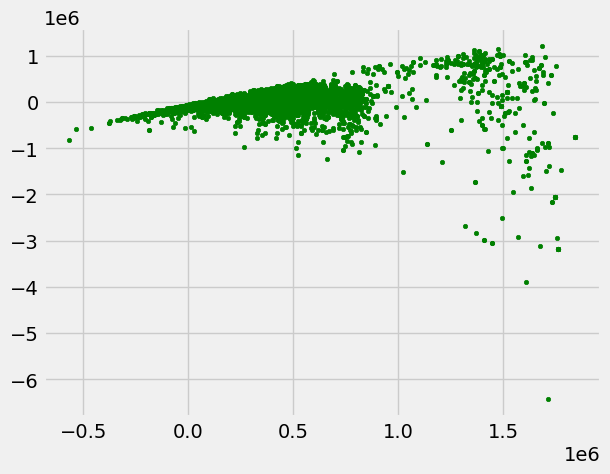

In [142]:
plt.scatter(regressor.predict(X_train),
            regressor.predict(X_train) - y_train,
            color = "green", s = 10, label = 'Train data')

## plotting residual errors in test data

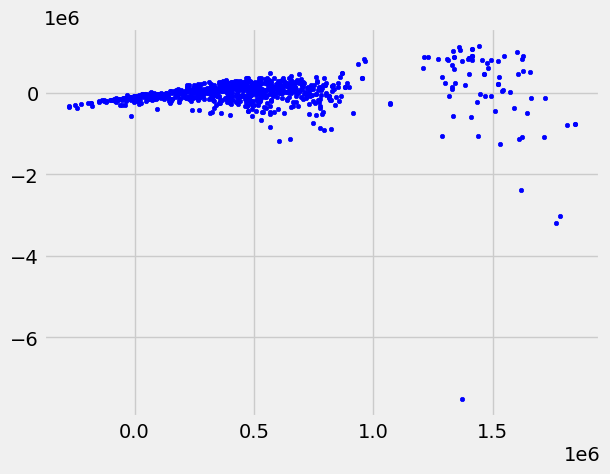

In [143]:
plt.scatter(regressor.predict(X_test),
            regressor.predict(X_test) - y_test,
            color = "blue", s = 10, label = 'Test data')

## plotting line for zero residual error

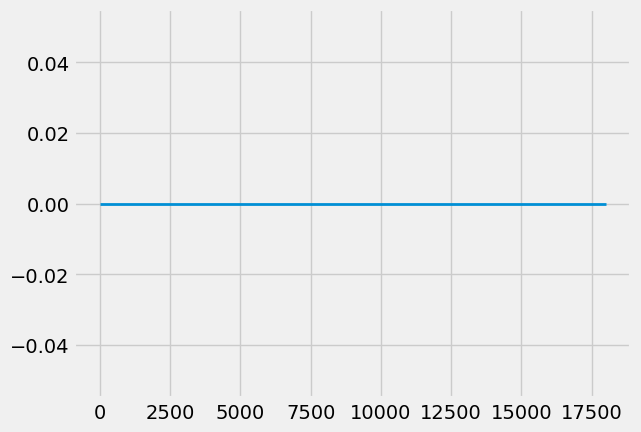

In [144]:
plt.hlines(y = 0, xmin = 0, xmax = 18000, linewidth = 2)

## plotting legend

<ipython-input-145-54cfbc54b345>:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc = 'upper right')


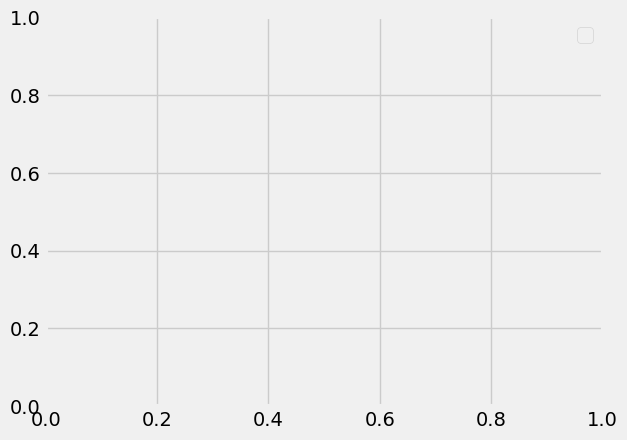

In [145]:
plt.legend(loc = 'upper right')

## plot title

Text(0.5, 1.0, 'Residual errors')

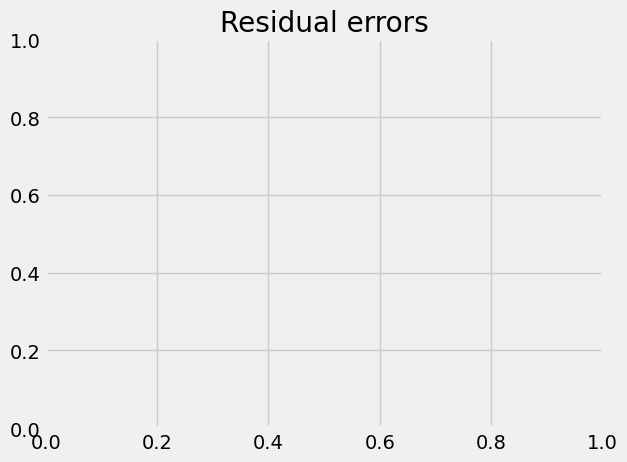

In [146]:
plt.title("Residual errors")

## function to show plot

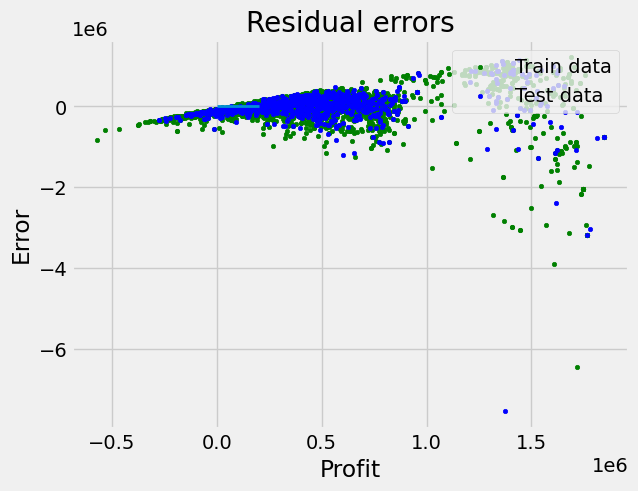

In [147]:
plt.style.use('fivethirtyeight')
plt.scatter(regressor.predict(X_train), regressor.predict(X_train) - y_train,color = "green", s = 10, label = 'Train data')
plt.scatter(regressor.predict(X_test), regressor.predict(X_test) - y_test,color = "blue", s = 10, label = 'Test data')
plt.hlines(y = 0, xmin = 0, xmax = 200000, linewidth = 2)
plt.legend(loc = 'upper right')
plt.title("Residual errors")
plt.xlabel("Profit")
plt.ylabel("Error")
plt.show()

### EVALUATING A MODEL USING R2 METRIC

#### Find the R^2

In [148]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.4031303601431171
